In [29]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, norm
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from numba import njit




# -------------------------
# Parameters
# -------------------------
N_side = 15
N = N_side**2
T = 2
M_side = int(np.sqrt(T * N))
M = M_side**2
c = 1/50
b = c * N
h = 1/(M-1)
#mu = 10/(h**2)
#rho = 20.3

mu = 6.5e5
rho = 1.3e4

max_iter = 50000
tau = 1e-15
tol = 4e-5
L = 1.0

# -------------------------
# Domain
# -------------------------
x = np.linspace(0, L, M_side)
X, Y = np.meshgrid(x, x)
collocation_pts = np.column_stack((X.ravel(), Y.ravel()))

cx = np.linspace(0, L, N_side)
CY, CX = np.meshgrid(cx, cx)
centers = np.column_stack((CX.ravel(), CY.ravel()))

# -------------------------
# Obstacle and solution
# -------------------------
#def psi(xy): return np.sin(np.pi * xy[:, 0]) * np.sin(np.pi * xy[:, 1])
#def analytical_u(xy): return np.maximum(0, psi(xy))


# -------------------------
# Obstacle and exact solution  (two bumps)
# -------------------------



def psi(xy, w=0.02, h_piece=1.0,  h_circle=0.75, r_circle=np.sqrt(0.005)):
    """
    Piece-wise block + circular bumps on [0,1]^2:
    """
    x, y = xy[:,0], xy[:,1]
    psi_vals = np.zeros_like(x)

    # Left block region
    mask_left = (np.abs(x-0.8) + np.abs(y - 0.6) <= w)
    psi_vals[mask_left] = h_piece



    # Circular bump region
    dx = x - 0.60
    dy = y - 0.25
    mask_circle = (dx*dx + dy*dy) < r_circle**2
    psi_vals[mask_circle] = h_circle

    return psi_vals






psi_vals = psi(collocation_pts)

# -------------------------
# RBF Kernel
# -------------------------
@njit
def rbf_fast(xy, centers, b):
    M, N = xy.shape[0], centers.shape[0]
    out = np.empty((M, N))
    for i in range(M):
        for j in range(N):
            dx = xy[i, 0] - centers[j, 0]
            dy = xy[i, 1] - centers[j, 1]
            r2 = dx * dx + dy * dy
            out[i, j] = np.exp(-b * b * r2)
    return out

Phi_raw = rbf_fast(collocation_pts, centers, b)
Phi = Phi_raw / np.sqrt(N)
dx = L / (M_side - 1)
A1 = dx**2 * Phi.T @ Phi

# -------------------------
# Boundary Conditions
# -------------------------
boundary_mask = (np.isclose(collocation_pts[:, 0], 0) |
                 np.isclose(collocation_pts[:, 0], L) |
                 np.isclose(collocation_pts[:, 1], 0) |
                 np.isclose(collocation_pts[:, 1], L))
Phi_bc = Phi[boundary_mask, :]
zero_bc = np.zeros(np.sum(boundary_mask))

beta = 3e5
A = A1 + beta * (Phi_bc.T @ Phi_bc)
lhs = A + rho * (Phi.T @ Phi)

# -------------------------
# SVD Solver
# -------------------------
U, S, VT = svd(lhs, full_matrices=False)
svd_tol = tau * np.max(S)
S_inv = np.where(S > svd_tol, 1 / S, 0)
def svd_solve(U, S_inv, VT, b): return VT.T @ (S_inv * (U.T @ b))

# -------------------------
# ADMM Initialization
# -------------------------
w = np.zeros(N)
v = Phi @ w
z = np.zeros(M)
primal_residuals, dual_residuals = [], []

# -------------------------
# ADMM Iteration
# -------------------------
for it in range(max_iter):
    rhs = rho * Phi.T @ (v - z) + beta * (Phi_bc.T @ zero_bc)
    w_new = svd_solve(U, S_inv, VT, rhs)
    ratio = mu * dx**2 / rho
    w_proj = Phi @ w_new + z
    v_new = np.maximum(w_proj - ratio, psi_vals)
    z_new = z + (Phi @ w_new - v_new)

    r_k = Phi @ w_new - v_new
    s_k = rho * Phi.T @ (v_new - v)

    norm_u = norm(Phi @ w_new)
    norm_v = norm(v_new)
    primal_res = norm(r_k) / max(norm_u, norm_v, tol)
    dual_res = norm(s_k) / max(norm(rho * Phi.T @ z), tol)

    primal_residuals.append(primal_res)
    dual_residuals.append(dual_res)

    if (it % 500 == 0) or (primal_res < tol and dual_res < tol):
        print(f"Iter {it}: Primal Residual = {primal_res:.2e}, Dual Residual = {dual_res:.2e}")
    if primal_res < tol and dual_res < tol:
        print(f"Converged at iteration {it}")
        break

    w, v, z = w_new, v_new, z_new

# -------------------------
# Post-processing
# -------------------------
u_rbf = Phi @ w
U_rbf = u_rbf.reshape(M_side, M_side)
Psi = psi_vals.reshape(M_side, M_side)
diff = U_rbf - Psi

Iter 0: Primal Residual = 1.00e+00, Dual Residual = 4.54e+08
Iter 500: Primal Residual = 7.69e-04, Dual Residual = 6.00e-04
Iter 1000: Primal Residual = 1.70e-04, Dual Residual = 9.14e-05
Iter 1500: Primal Residual = 8.52e-05, Dual Residual = 9.72e-05
Iter 2000: Primal Residual = 7.16e-05, Dual Residual = 2.94e-05
Iter 2500: Primal Residual = 3.05e-05, Dual Residual = 8.51e-05
Iter 2596: Primal Residual = 3.99e-05, Dual Residual = 3.35e-05
Converged at iteration 2596


Number of Basis Function(s): 225
Grid Size (m x m): (441x441)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

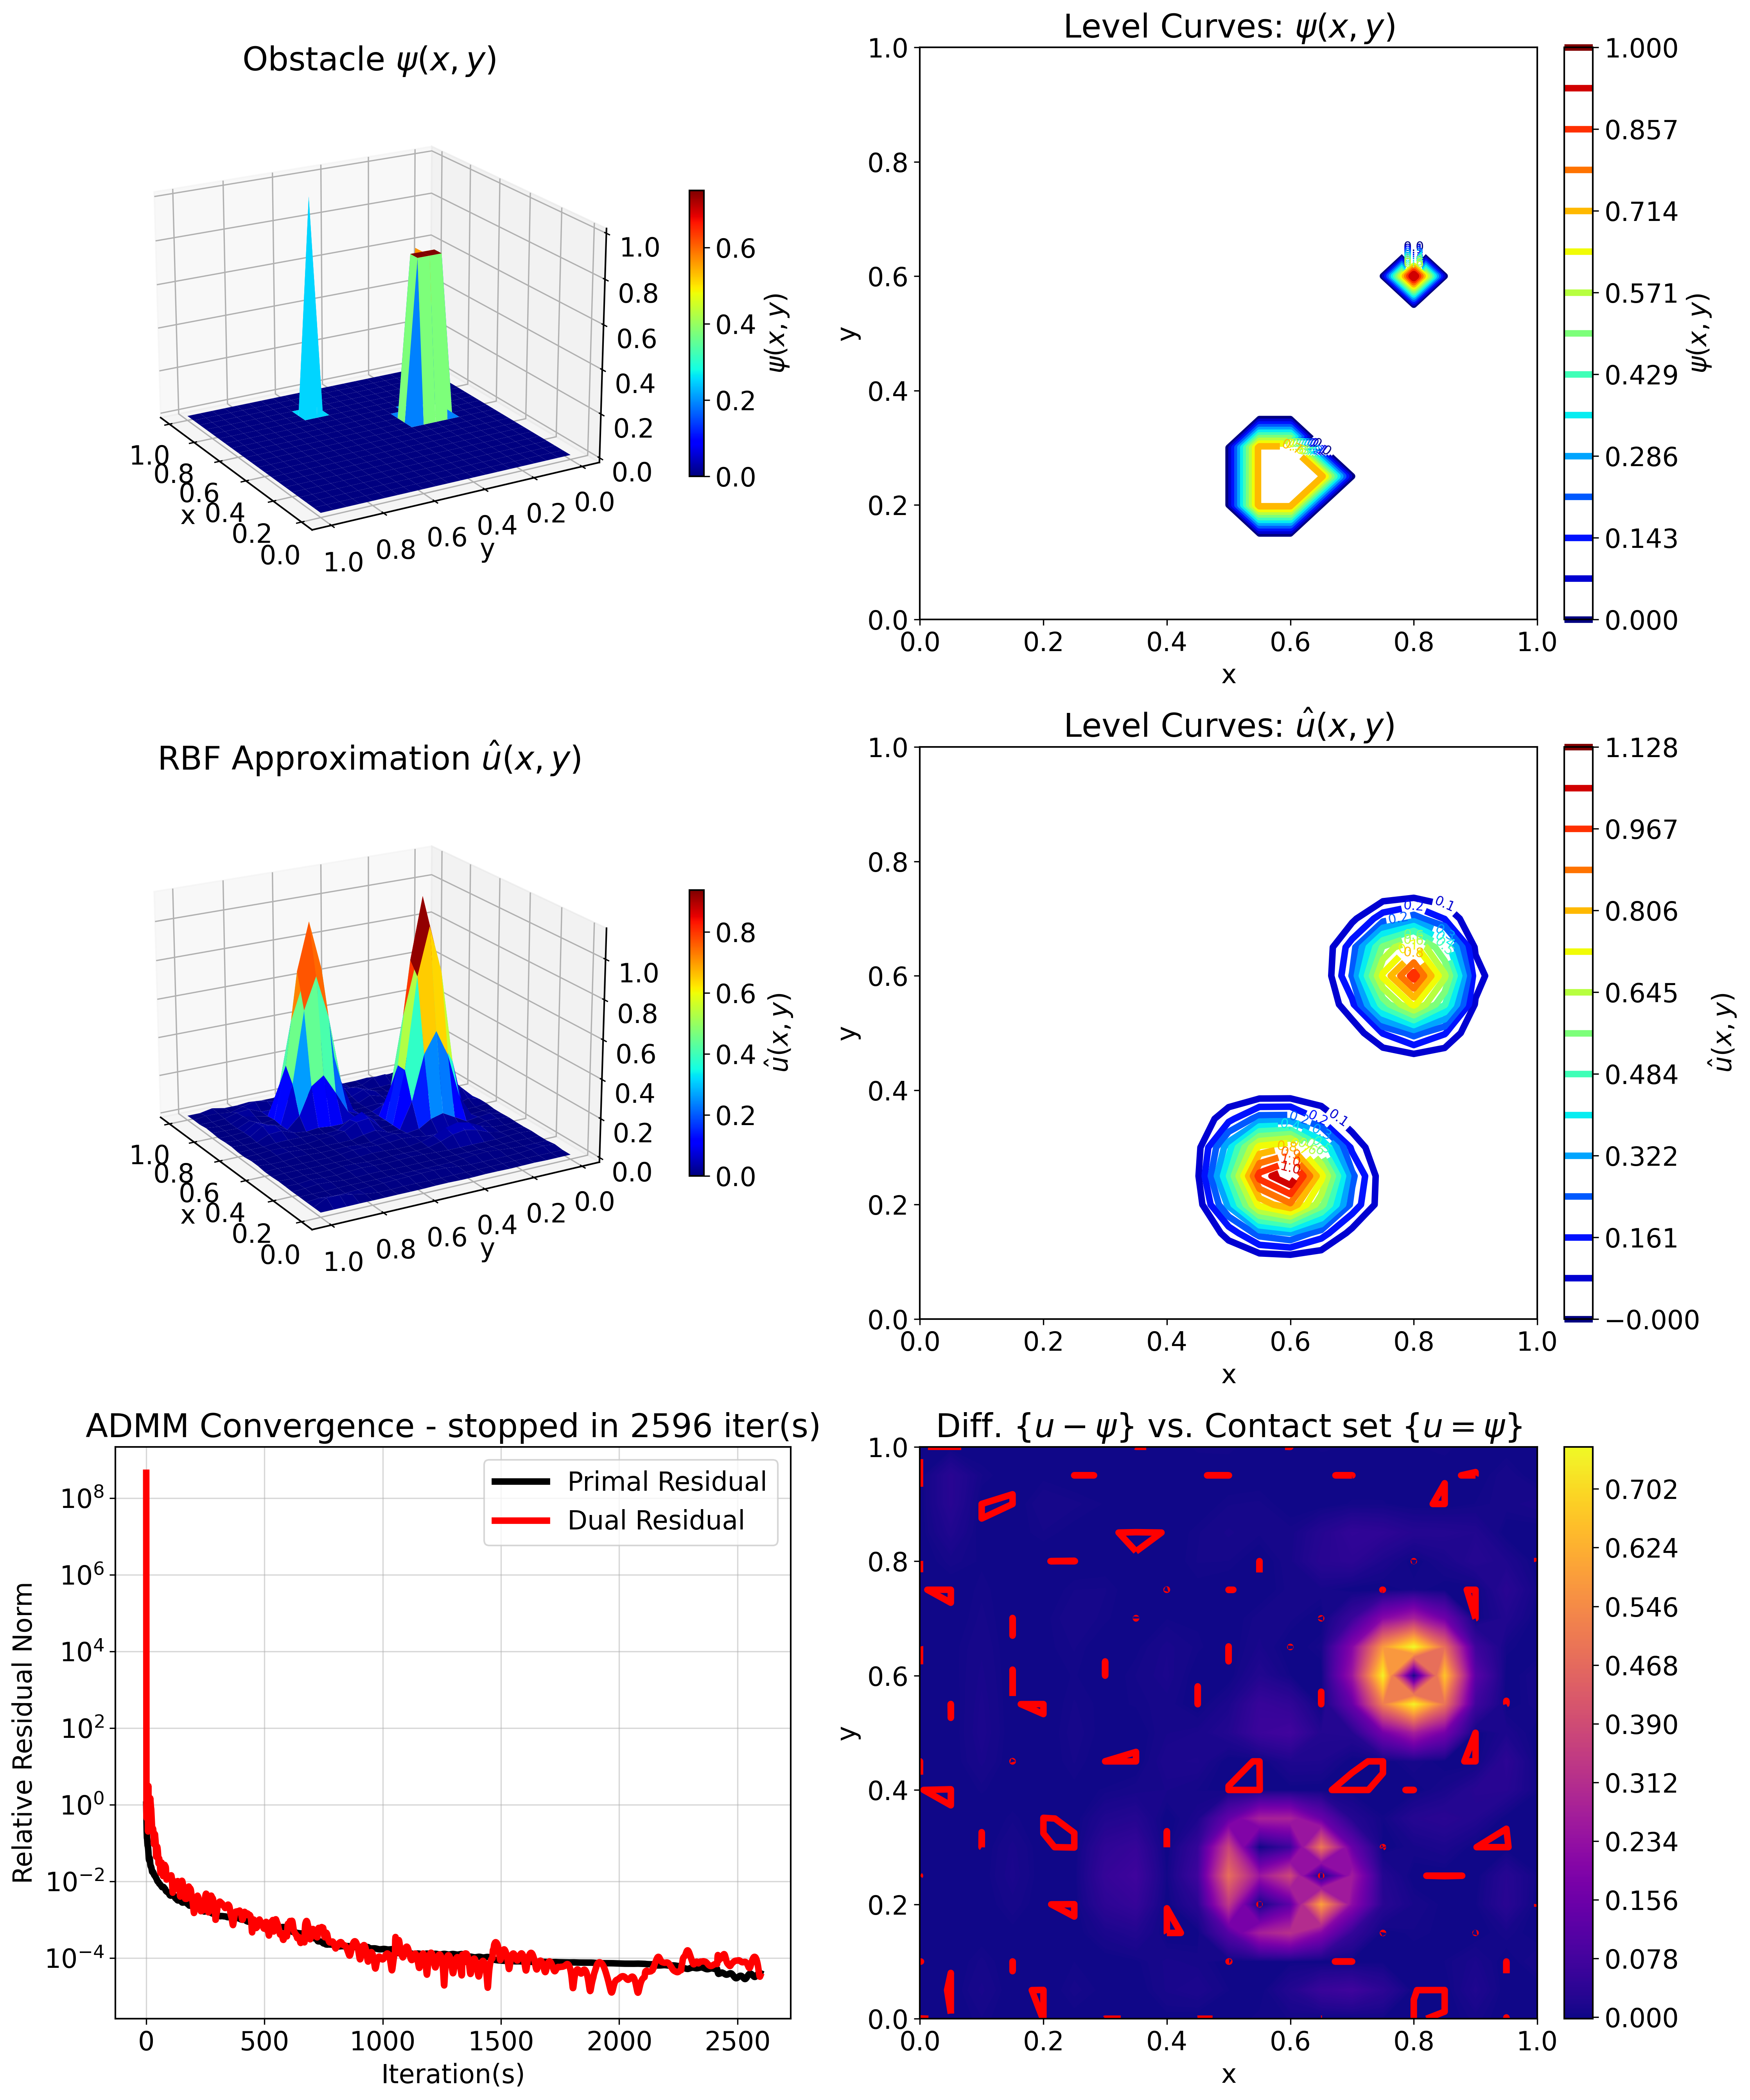

In [30]:
from google.colab import files
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})

print(f'Number of Basis Function(s): {N}')
print(f'Grid Size (m x m): ({M}x{M})')

# -------------------------
# Plot
# -------------------------
fig = plt.figure(figsize=(15, 18))

# Row 1: 3D Obstacle Function
ax1 = fig.add_subplot(3, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, Psi, cmap='jet', edgecolor='none')
ax1.set_title('Obstacle $\psi(x,y)$')
# turn off the background grid lines
#ax1.grid(False)
ax1.set_xlabel('x'); ax1.set_ylabel('y');
ax1.view_init(elev=20, azim=150)
#ax1.set_zlabel('u')
# add a colorbar for this surface
fig.colorbar(surf,
             ax=ax1,
             shrink=0.5,
             pad=0.1,
             label='$\psi(x,y)$')




ax2 = fig.add_subplot(3, 2, 2)
# Level curves of obstacle function
levels = np.linspace(Psi.min(), Psi.max(), 15)
cs = ax2.contour(X, Y, Psi, levels=levels, cmap='jet')
ax2.clabel(cs, inline=True, fontsize=8, fmt="%.1f")   # optional labels on curves
ax2.set_title('Level Curves: $\psi(x,y)$')
ax2.set_xlabel('x'); ax2.set_ylabel('y')

fig.colorbar(cs, ax=ax2, fraction=0.046, pad=0.04, label='$\psi(x,y)$')





# Row 2: Approximation
ax3 = fig.add_subplot(3, 2, 3, projection = '3d')
surf_3 = ax3.plot_surface(X, Y, U_rbf, cmap='jet', edgecolor='none')
ax3.set_title('RBF Approximation $\hat{u}(x,y)$')
# turn off the background grid lines
#ax2.grid(False)
ax3.set_xlabel('x'); ax3.set_ylabel('y');
#ax3.set_zlabel('$\hat{u}$')
# add a colorbar for this surface
ax3.view_init(elev=20, azim=150)
fig.colorbar(surf_3,
             ax=ax3,
             shrink=0.5,
             pad=0.1,
             label='$\hat{u}(x,y)$')





# Level Curves
ax4 = fig.add_subplot(3, 2, 4)
levels = np.linspace(U_rbf.min(), U_rbf.max(), 15)
cs = ax4.contour(X, Y, U_rbf, levels=levels, cmap='jet')
ax4.clabel(cs, inline=True, fontsize=8, fmt="%.1f")   # optional labels on curves
ax4.set_title('Level Curves: $\hat{u}(x,y)$')
ax4.set_xlabel('x'); ax4.set_ylabel('y')
fig.colorbar(cs, ax=ax4, fraction=0.046, pad=0.04, label='$\hat{u}(x,y)$')



# Row 3: ADMM Convergence
ax5 = fig.add_subplot(3, 2, 5)
ax5.semilogy(primal_residuals, label='Primal Residual', color = 'black')
ax5.semilogy(dual_residuals, label='Dual Residual', color = 'red')
ax5.set_title(f'ADMM Convergence - stopped in {it:2d} iter(s)')
ax5.set_xlabel('Iteration(s)'); ax5.set_ylabel('Relative Residual Norm')
ax5.legend(); ax5.grid(True)


# Difference and Contact Set.
ax6 = fig.add_subplot(3, 2, 6)
diff = U_rbf - Psi
cf6 = ax6.contourf(X, Y, diff, levels= 500, cmap='plasma')
ax6.contour(X, Y, diff, levels=[0], colors='red', linestyles='-')
ax6.set_title(r'Diff. $\{u - \psi\}$ vs. Contact set $\{u = \psi\}$')
ax6.set_xlabel('x'); ax6.set_ylabel('y')
fig.colorbar(cf6, ax=ax6, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.savefig('fig1_obstacle_2D_piecewise.png')
files.download('fig1_obstacle_2D_piecewise.png')

# Benchmark Performance

In [15]:
import numpy as np
import time
import tracemalloc
from numpy.linalg import svd, norm
from numba import njit

def solve_rbf_admm(N_side, T=2, mu=6.5e5, rho=1.3e4,
                   max_iter=20_000, tau=1e-15, tol=5e-5,
                   L=1.0, beta=3e5, c = 1/20):
    # start tracking
    tracemalloc.start()
    t0 = time.perf_counter()

    # setup sizes
    N = N_side**2
    M_side = int(np.sqrt(T * N))
    M = M_side**2
    b = c * N

    # build points
    x = np.linspace(0, L, M_side)
    X, Y = np.meshgrid(x, x)
    pts = np.column_stack((X.ravel(), Y.ravel()))
    cx = np.linspace(0, L, N_side)
    CY, CX = np.meshgrid(cx, cx)
    centers = np.column_stack((CX.ravel(), CY.ravel()))

    # obstacle and boundary funcs
    def psi(xy, w=0.02, h_piece=1.0,  h_circle=0.75, r_circle=np.sqrt(0.005)):
      """
      Piece-wise block + circular bumps on [0,1]^2:
      """
      x, y = xy[:,0], xy[:,1]
      psi_vals = np.zeros_like(x)

      # Left block region
      mask_left = (np.abs(x-0.8) + np.abs(y - 0.6) <= w)
      psi_vals[mask_left] = h_piece



      # Circular bump region
      dx = x - 0.60
      dy = y - 0.25
      mask_circle = (dx*dx + dy*dy) < r_circle**2
      psi_vals[mask_circle] = h_circle

      return psi_vals

    psi_vals = psi(pts)

    # -------------------------
    # RBF Kernel
    # -------------------------


    # fast RBF
    @njit
    def rbf_fast(xy, centers, b):
        M_, N_ = xy.shape[0], centers.shape[0]
        out = np.empty((M_, N_))
        for i in range(M_):
            for j in range(N_):
                dx = xy[i,0]-centers[j,0]; dy = xy[i,1]-centers[j,1]
                out[i,j] = np.exp(-b*b*(dx*dx+dy*dy))
        return out

    Phi = rbf_fast(pts, centers, b)/np.sqrt(N)
    dx = L/(M_side-1)
    A1 = dx*dx*(Phi.T@Phi)

    bc_mask = (pts[:,0]==0)|(pts[:,0]==L)|(pts[:,1]==0)|(pts[:,1]==L)
    Phi_bc = Phi[bc_mask]
    gb = np.zeros(np.sum(bc_mask)) # zero boundary conditions.

    # system matrix
    A_mat = A1 + beta*(Phi_bc.T@Phi_bc) + rho*(Phi.T@Phi)

    # precompute SVD
    U,S,VT = svd(A_mat, full_matrices=False)
    thresh = tau*S.max()
    Sinv = np.where(S>thresh, 1/S, 0)
    def solve_svd(rhs):
        return VT.T @ (Sinv*(U.T@rhs))

    # ADMM initialize
    w = np.zeros(N); v = Phi@w; z = np.zeros(M)
    psi_vals = psi(pts)

    for it in range(max_iter):
        rhs = rho*(Phi.T@(v-z)) + beta*(Phi_bc.T@gb)
        w_new = solve_svd(rhs)
        proj = Phi@w_new + z
        v_new = np.maximum(proj - mu*dx*dx/rho, psi_vals)
        z_new = z + (Phi@w_new - v_new)

        # check convergence
        if norm(Phi@w_new - v_new)<tol and norm(rho*(Phi.T@(v_new-v)))<tol:
            break
        w,v,z = w_new,v_new,z_new

    # compute error
    u_approx = (Phi@w).reshape(M_side, M_side)


    # stop tracking
    comp_time = time.perf_counter()-t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory_usage = peak / 1024**2

    return N, M, memory_usage, comp_time

In [17]:
# Define the list of N_side values you want to benchmark
N_sides = [2, 5, 10, 15, 20, 25, 30, 35]
c_vals = [1/20,1/20, 1/20, 1/20, 1/20, 1/20, 1/20, 1/20]

# Prepare an empty list to collect results
results = []

for (Ns, c_val) in zip(N_sides, c_vals):
    # Run the solver: returns (rel_error, memory_MB, time_sec, M_grid)
    N, m, mem, t= solve_rbf_admm(Ns, c = c_val)
    print(f'N: {N:2d} | Gridsize: (m x m) = ({m:2d} x {m:2d}) | Memory Storage (MB): {mem:.3f} | Comp. Time (sec.): {t:.3f}')

    # Append a tuple (or dict) with all metrics
    results.append({
        'N':         N,
        'm_grid':    m,
        'memory_MB': mem,
        'comp_time':  t
    })



N:  4 | Gridsize: (m x m) = ( 4 x  4) | Memory Storage (MB): 1.476 | Comp. Time (sec.): 0.571
N: 25 | Gridsize: (m x m) = (49 x 49) | Memory Storage (MB): 1.478 | Comp. Time (sec.): 0.581
N: 100 | Gridsize: (m x m) = (196 x 196) | Memory Storage (MB): 1.560 | Comp. Time (sec.): 8.254
N: 225 | Gridsize: (m x m) = (441 x 441) | Memory Storage (MB): 3.896 | Comp. Time (sec.): 12.154
N: 400 | Gridsize: (m x m) = (784 x 784) | Memory Storage (MB): 9.082 | Comp. Time (sec.): 5.524
N: 625 | Gridsize: (m x m) = (1225 x 1225) | Memory Storage (MB): 19.945 | Comp. Time (sec.): 18.679
N: 900 | Gridsize: (m x m) = (1764 x 1764) | Memory Storage (MB): 39.595 | Comp. Time (sec.): 98.208
N: 1225 | Gridsize: (m x m) = (2401 x 2401) | Memory Storage (MB): 71.727 | Comp. Time (sec.): 68.115


Memory fit: MB = 1.221e-05·m^2 + 1.457e+00
Time fit: Time = 8.696e-02·N^0.891


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

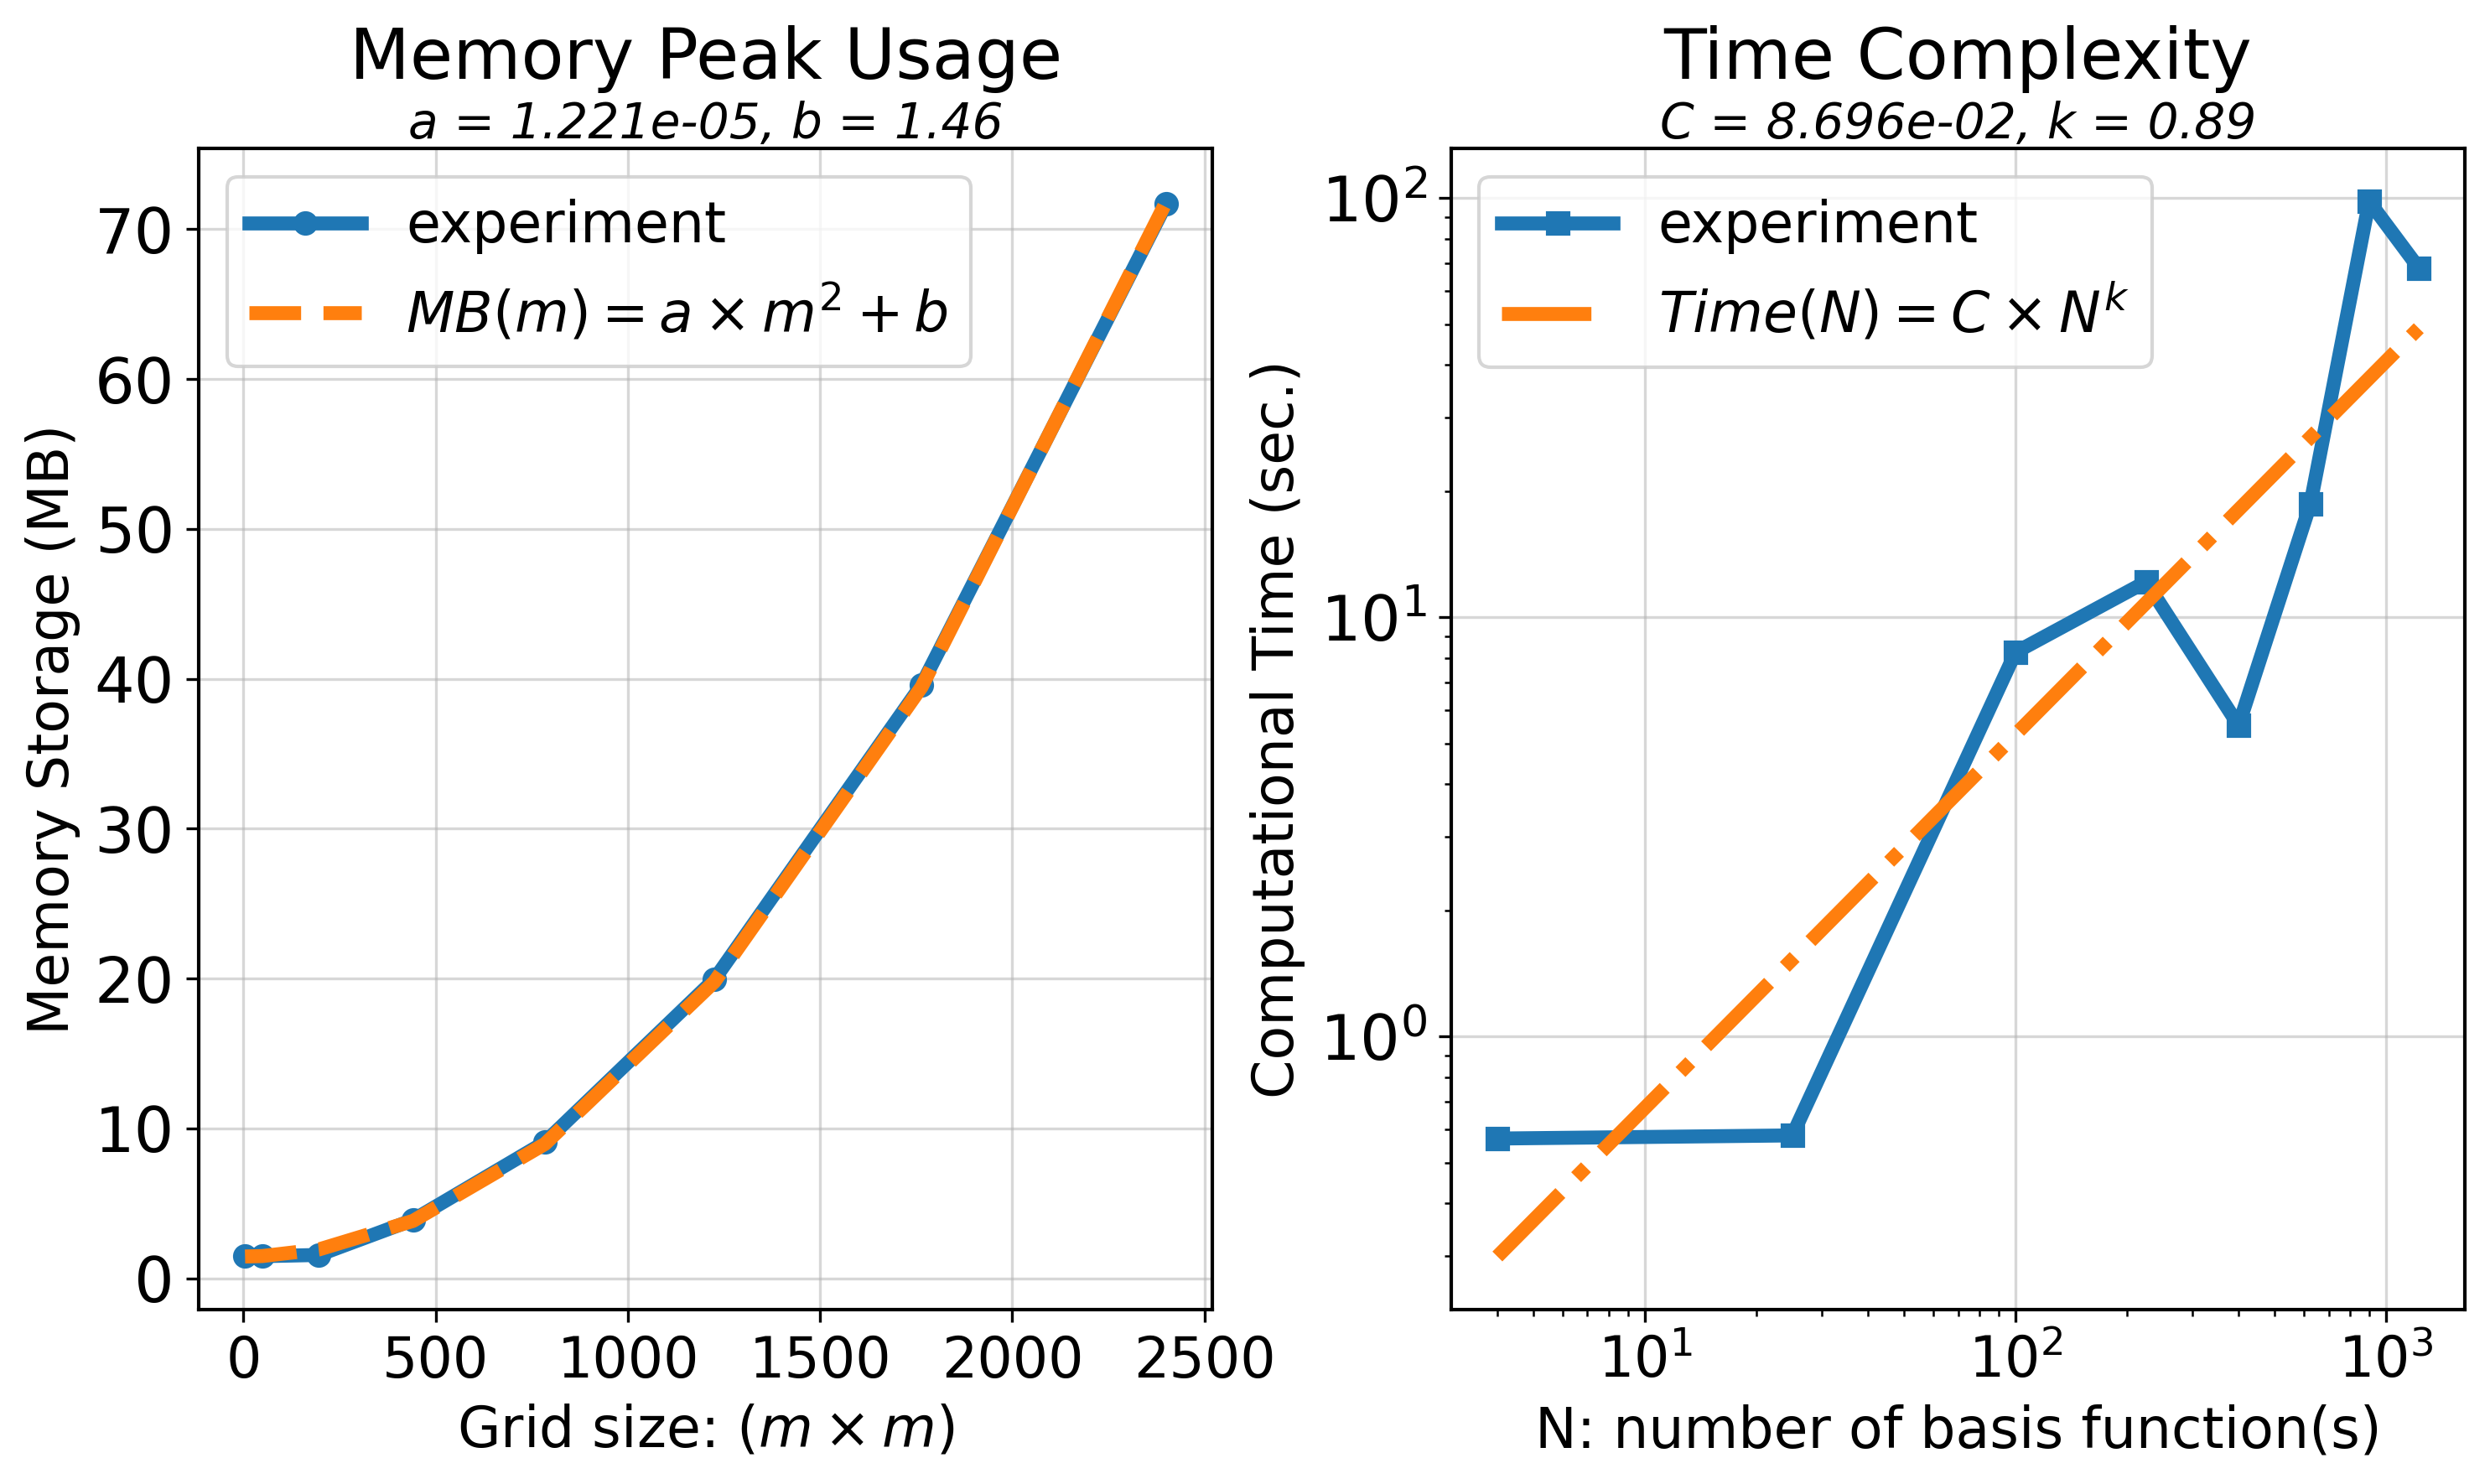

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import files
import numpy as np


plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})


# Assuming `results` is a list of dicts with keys:
# 'N', 'M_grid', 'memory_MB', 'time_sec', 'rel_error'

# Extract data
m_vals      = np.array([r['m_grid']    for r in results])
memory_vals = np.array([r['memory_MB'] for r in results])
N_vals      = np.array([r['N']         for r in results])
time_vals   = np.array([r['comp_time']  for r in results])



# 1. Memory ~ a * M^2 + b
X1 = np.vstack([m_vals**2, np.ones_like(m_vals)]).T
a, b = np.linalg.lstsq(X1, memory_vals, rcond=None)[0]
print(f"Memory fit: MB = {a:.3e}·m^2 + {b:.3e}")

# 2. Time ~ C * N^k (log–log fit)
lnN, lnt = np.log(N_vals), np.log(time_vals)
k, lnC = np.polyfit(lnN, lnt, 1)
C = np.exp(lnC)
print(f"Time fit: Time = {C:.3e}·N^{k:.3f}")




# Create figure and gridspec
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), tight_layout=True)

# Top-left: Memory vs Grid Size

ax1.plot(m_vals, memory_vals, 'o-', linewidth=4, color = 'tab:blue', label = 'experiment')
ax1.plot(m_vals, a * m_vals**2 + b, '--', linewidth=4, color = 'tab:orange', label = f'$MB(m) = a \\times m^2 + b$')
ax1.legend(frameon = True)
ax1.set_xlabel(f'Grid size: $(m \\times m)$')
ax1.set_ylabel('Memory Storage (MB)')
ax1.set_title('Memory Peak Usage', pad = 20)
ax1.text(
    0.5, 1.0,
    f'a = {a:.3e}, b = {b:.2f}',
    transform=ax1.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontstyle="italic"
)

ax1.grid(True)

# Top-right: Time Complexity (log-log)

ax2.loglog(N_vals, time_vals, 's-', linewidth=4, label = 'experiment', color = 'tab:blue')
ax2.loglog(N_vals, C * N_vals**k, '-.', linewidth=4, label = f'$Time(N) = C \\times N^k$', color = 'tab:orange')
ax2.legend(frameon = True)
ax2.set_xlabel('N: number of basis function(s)')
ax2.set_ylabel('Computational Time (sec.)')
ax2.set_title('Time Complexity', pad = 20)
ax2.text(
    0.5, 1.0,
    f'C = {C:.3e}, k = {k:.2f}',
    transform=ax2.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontstyle="italic"
)
ax2.grid(True)


plt.tight_layout()
plt.savefig('fig2_obstacle_2D_piecewise.png')
files.download('fig2_obstacle_2D_piecewise.png')